# Analysis and visualisation

### Installing libraries and importing modules

In [5]:
!pip install pandas

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as mtick
from matplotlib.ticker import FuncFormatter

### ONS - General Health 2011 / 2021

#### Reading the cleaned data

In [7]:
census_health_sex = pd.read_csv("../data/clean/cleaned_census_health_sex.csv")
census_health_sex.head()

,year,country,health_status,sex,count,population,age_standardised_percentage,lower_95pct_confidence_interval,upper_95pct_confidence_interval
0,2021,England,Very good,Female,13653975,28833720,47.1,47.1,47.2
1,2021,England,Very good,Male,13736855,27656330,47.9,47.9,48.0
2,2021,England,Good,Female,9769630,28833720,34.2,34.1,34.2
3,2021,England,Good,Male,9271115,27656330,34.2,34.1,34.2
4,2021,England,Fair,Female,3807185,28833720,13.2,13.2,13.2


#### Health status by sex (2021)- How do men and women differ in self-reported health today?

In [8]:
# Filtering to 2021 DF
health_2021 = census_health_sex[census_health_sex["year"] == 2021]

In [9]:
# Prepping for visualisation

pivot_2021 = health_2021.pivot_table(
    index="health_status",
    columns="sex",
    values="age_standardised_percentage"
)

pivot_2021

sex,Female,Male
health_status,,
Bad,4.85,4.40
Fair,13.75,13.30
Good,33.35,33.40
Very bad,1.40,1.40
Very good,46.60,47.55


#### Self-Rated Health by sex

<Figure size 1000x600 with 0 Axes>

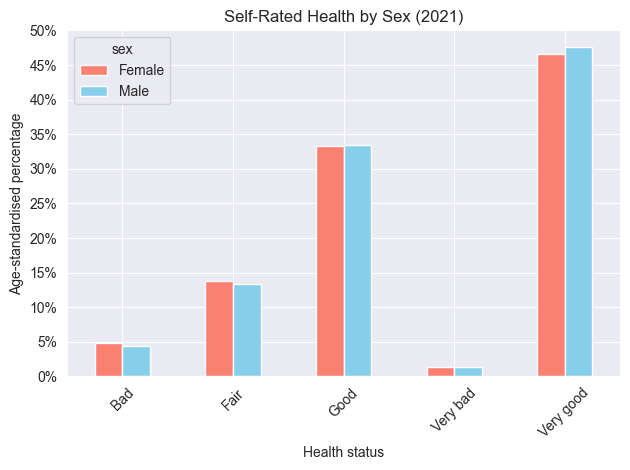

In [10]:
plt.figure(figsize=(10,6))

# Defining colours
my_colours = ['salmon', 'skyblue']

# Passing the colour argument
ax = pivot_2021.plot(kind="bar", color=my_colours)

# The rest of your styling remains exactly the same
ax.set_title("Self-Rated Health by Sex (2021)")
ax.set_xlabel("Health status")
ax.set_ylabel("Age-standardised percentage")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0f}%")

# Add more tick marks for readability
ax.set_yticks(range(0, 55, 5))  # 0%, 5%, 10%, ..., 50%

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Plot summary:**

- Most men and women report their health as either “Good” or “Very good”
- Men are slightly more likely to report “Very good” health than women
- Women are slightly more represented in the “Fair” and “Bad” categories
- The overall pattern is very similar between sexes, with only small differences across categories
- “Very bad” health is a very small proportion for both groups

**Interpretation (safe and accurate)**

- The data suggests subtle but measurable differences in how men and women rate their health
- These figures reflect population-level health patterns, not healthcare usage or cost
- The chart provides context, which may help explain differences later seen in NHS activity or spending data.

#### Change in 'Very Good' Self-Rated Health (2011-2021)

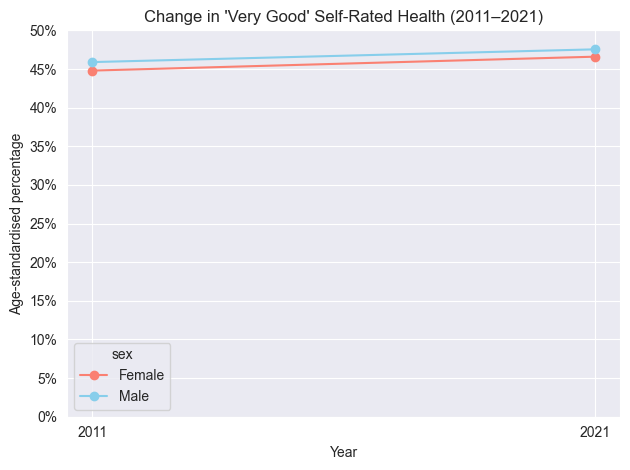

In [11]:
# Filtering to just the "Very good" category
very_good = census_health_sex[census_health_sex["health_status"] == "Very good"]

# Creating a pivot table
pivot_vg = very_good.pivot_table(
    index="year",
    columns="sex",
    values="age_standardised_percentage"
)

my_colours = ['salmon', 'skyblue']

# Plotting as a line chart with the specific colours
ax = pivot_vg.plot(marker="o", color=my_colours)

# Titles and labels
ax.set_title("Change in 'Very Good' Self-Rated Health (2011–2021)")
ax.set_xlabel("Year")
ax.set_ylabel("Age-standardised percentage")

# Showing years clearly on x-axis
plt.xticks([2011, 2021])

# Showing more y-axis detail (every 5%)
ax.set_yticks(range(0, 55, 5))
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0f}%")

# Cleaning layout
plt.tight_layout()
plt.show()

**Plot summary:**

- Both men and women report a small increase in “Very good” health over time
- Men consistently report slightly higher levels than women
- The difference between sexes has remained narrow and stable
- This indicates a broadly similar trend for both groups across the decade

#### Overall Health Profile by Sex (2021)

<Figure size 1000x600 with 0 Axes>

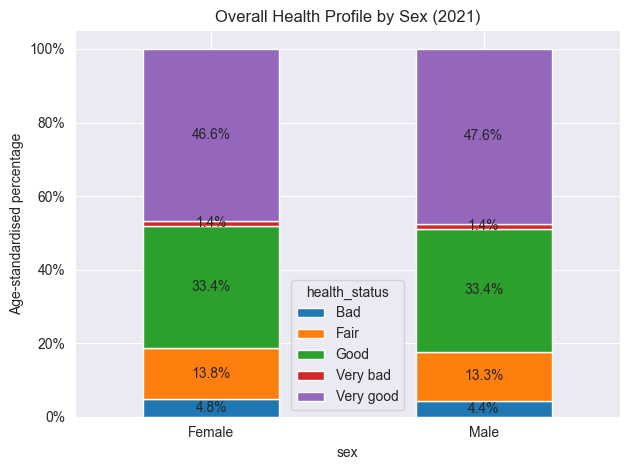

In [12]:
# Filtering to 2021 data
health_2021 = census_health_sex[census_health_sex["year"] == 2021]

# Pivoting for stacked bar
stacked = health_2021.pivot_table(
    index="sex",
    columns="health_status",
    values="age_standardised_percentage"
)

# Plotting
plt.figure(figsize=(10,6))
ax = stacked.plot(kind="bar", stacked=True)

# Axis formatting
ax.set_title("Overall Health Profile by Sex (2021)")
ax.set_ylabel("Age-standardised percentage")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0f}%")
plt.xticks(rotation=0)

# Adding % labels to each segment
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center")

plt.tight_layout()
plt.show()

**Plot summary:**

- Both genders are heavily concentrated in “Very good” and “Good” health categories
- Overall shape of the distribution is very similar for men and women
- Men show a slightly larger share in the “Very good” category
- Women show slightly higher representation in “Fair” and “Bad” categories
- The differences are present but not large in scale
- The stacked distribution shows that health outcomes are broadly similar between men and women. Minor differences exist, but there is no evidence of a major structural gap based on this dataset alone.

#### 10-Year trend: Percentage Reporting Poor Health (England)

In [13]:
df = census_health_sex

# Filtering to England (that's what we decided to focus on per the proposal) & grouping all bad results

df_england = df[df['country'] == 'England'].copy()
df_bad = df_england[df_england['health_status'].isin(['Bad', 'Very bad'])].copy()


# Calculating the %ges

trend_data = df_bad.groupby(['year', 'sex'])['age_standardised_percentage'].sum().reset_index()
pivot_trend = trend_data.pivot(index='year', columns='sex', values='age_standardised_percentage')

display(pivot_trend)

sex,Female,Male
year,,
2011,5.9,6.0
2021,5.5,5.1


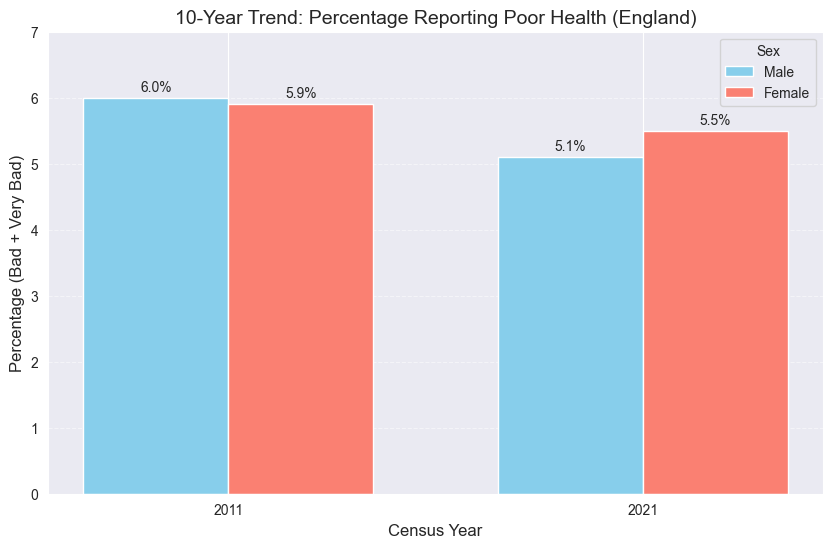

In [14]:
# Plotting

plt.figure(figsize=(10, 6))

years = pivot_trend.index  # [2011, 2021]
x_pos = np.arange(len(years))
width = 0.35


# Plotting Bars
plt.bar(x_pos - width/2, pivot_trend['Male'], width, label='Male', color='skyblue')
plt.bar(x_pos + width/2, pivot_trend['Female'], width, label='Female', color='salmon')


# Labels and Title
plt.title('10-Year Trend: Percentage Reporting Poor Health (England)', fontsize=14)
plt.ylabel('Percentage (Bad + Very Bad)', fontsize=12)
plt.xlabel('Census Year', fontsize=12)
plt.xticks(x_pos, years) # X-axis shows 2011 and 2021
plt.ylim(0, pivot_trend.max().max() + 1) # adding space


# Adding the numbers on top of the bars
for i, year in enumerate(years):
    # Male Label
    m_val = pivot_trend.loc[year, 'Male']
    plt.text(i - width/2, m_val + 0.1, f'{m_val:.1f}%', ha='center') # position of the text

    # Female Label
    f_val = pivot_trend.loc[year, 'Female']
    plt.text(i + width/2, f_val + 0.1, f'{f_val:.1f}%', ha='center')

plt.legend(title='Sex')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

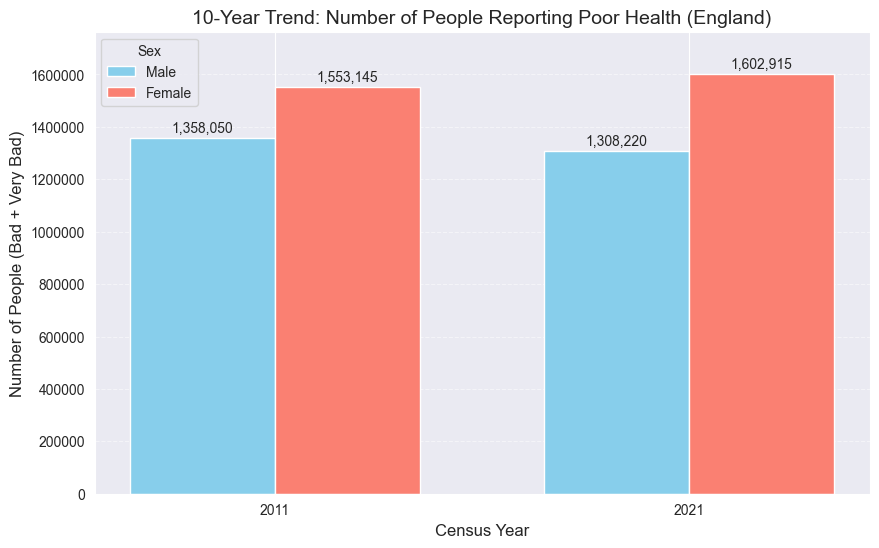

In [15]:
# same as above, but with numbers instead of percentages:


trend_data_counts = df_bad.groupby(['year', 'sex'])['count'].sum().reset_index()
pivot_trend_counts = trend_data_counts.pivot(index='year', columns='sex', values='count')

# display(pivot_trend_counts)


plt.figure(figsize=(10, 6))

years = pivot_trend_counts.index
x_pos = np.arange(len(years))
width = 0.35

# Plot Bars
plt.bar(x_pos - width/2, pivot_trend_counts['Male'], width, label='Male', color='skyblue')
plt.bar(x_pos + width/2, pivot_trend_counts['Female'], width, label='Female', color='salmon')

# Labels and Title
plt.title('10-Year Trend: Number of People Reporting Poor Health (England)', fontsize=14)
plt.ylabel('Number of People (Bad + Very Bad)', fontsize=12)
plt.xlabel('Census Year', fontsize=12)
plt.xticks(x_pos, years)
plt.ylim(0, pivot_trend_counts.max().max() * 1.1) # add 10% padding to the top
plt.ticklabel_format(style='plain', axis='y')

# Text Labels
for i, year in enumerate(years):
    # Male Label
    m_val = pivot_trend_counts.loc[year, 'Male']
    # Format as a whole number with a comma separator
    plt.text(i - width/2, m_val + 20000, f'{m_val:,.0f}', ha='center')

    # Female Label
    f_val = pivot_trend_counts.loc[year, 'Female']
    plt.text(i + width/2, f_val + 20000, f'{f_val:,.0f}', ha='center')

plt.legend(title='Sex')
plt.grid(axis='y', linestyle='--', alpha=0.5)

**Plots summary:**

- The percentage of both men and women reporting poor health decreased between 2011 and 2021, indicating an overall improvement in self-reported health in England
- Men saw a larger drop in the rate of poor health, decreasing by 0.9 percentage points (from 6.0% to 5.1%). Women's rate also improved, but by a smaller margin of 0.4 percentage points (from 5.9% to 5.5%)
- The data shows a flip in which gender reports a higher rate of poor health. In 2011, a slightly higher percentage of men reported poor health than women. By 2021, this reversed, with a slightly higher percentage of women reporting poor health
- Despite the percentage decrease, the absolute number of women reporting poor health actually rose slightly between 2011 and 2021 (from 1.55M to 1.60M). In contrast, the absolute number of men reporting poor health fell (from 1.36M to 1.31M)
- While England's overall health has improved on a percentage basis for both genders over the decade, the gains were more significant for men. The rising absolute number of women with poor health, despite a falling percentage, likely points to demographic factors like population growth and underscores that the total healthcare burden for this group may still be increasing



### Dataset 2

## Visualising NHS Demographics- Male vs Female by Ethnic Group

In [16]:
# Make plots bigger as default
plt.rcParams['figure.figsize'] = (10,6)

In [17]:
# Path to the clean demographics datasets
csv_path = '../data/clean/demographics_ethnic_sex_clean.csv'

demog_sex_df = pd.read_csv(csv_path)

demog_sex_df.head()

,Ethnic_Code,Ethnic_Description,Total_FCE,Total_FAE,Male_FCE,Female_FCE
0,A,British (White),14647984,11765955,6605131,7955166
1,B,Irish (White),143887,110968,65525,77279
2,C,Any other White background,963874,816817,391041,563634
3,D,White and Black Caribbean (Mixed),70872,62743,25736,44619
4,E,White and Black African (Mixed),38271,33925,14997,22887


In [18]:
# Checking columns and data types

demog_sex_df.dtypes

Ethnic_Code           object
Ethnic_Description    object
Total_FCE              int64
Total_FAE              int64
Male_FCE               int64
Female_FCE             int64
dtype: object

1: Overall hospital usage by sex

This chart shows the total number of Finished Consultant Episodes (FCSs) for men and women across all ethnic groups combined

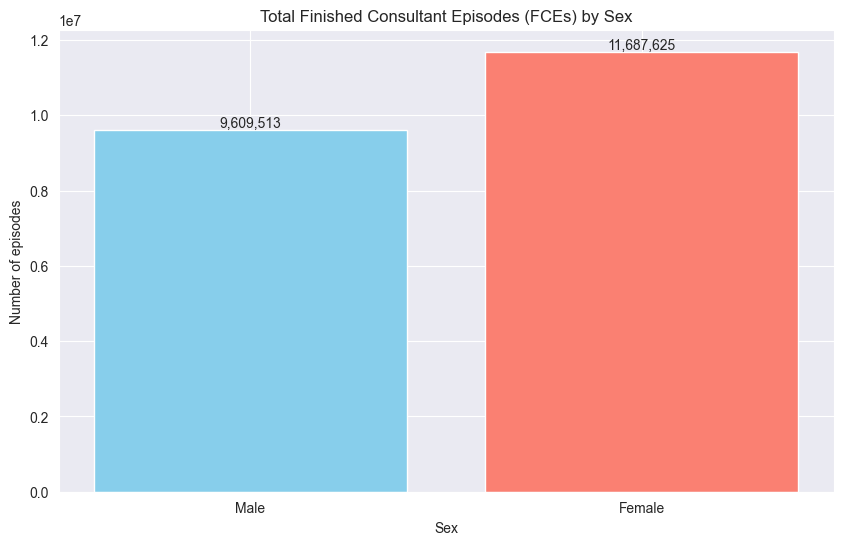

In [19]:
# Sum of male and female FCEs across all ethnic groups

total_male_fce = demog_sex_df['Male_FCE'].sum()
total_female_fce = demog_sex_df['Female_FCE'].sum()

# Creating bar chart
sex_labels = ['Male', 'Female']
totals = [total_male_fce, total_female_fce]

plt.figure()
plt.bar(sex_labels, totals, color=['skyblue', 'salmon'])
plt.title('Total Finished Consultant Episodes (FCEs) by Sex')
plt.xlabel('Sex')
plt.ylabel('Number of episodes')

# Show values on top of bars for clarity
for i, value in enumerate(totals):
    plt.text(i, value, f'{value:,}', ha='center', va='bottom')

plt.show()

2: Male vs Female by ethnic group

This chart shows, for the 10 ethnic groups with the highest number of hospital episodes, how many were FCEs were for men vs women

<function matplotlib.pyplot.show(close=None, block=None)>

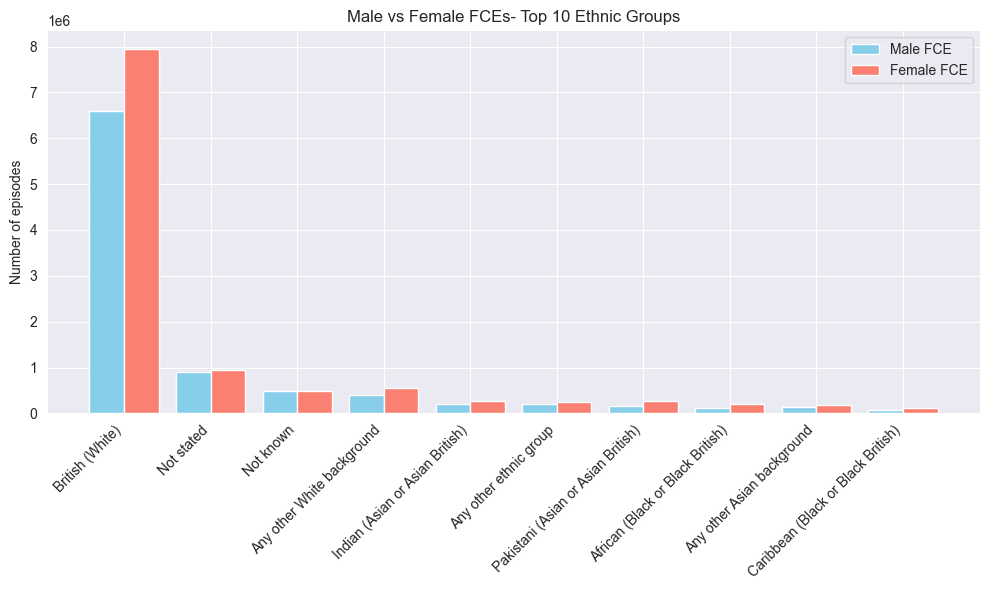

In [20]:
# Sorting by FCE and taking the top 10 ethnic groups
top10 = demog_sex_df.sort_values('Total_FCE', ascending=False).head(10)

x = range(len(top10))

width = 0.4

plt.figure()

# Moving the bars to stop them overlapping
plt.bar([i-width/2 for i in x], top10['Male_FCE'], width=width, label='Male FCE',color='skyblue')
plt.bar([i+width/2 for i in x], top10['Female_FCE'], width=width, label='Female FCE', color='salmon')

# Axis labels
plt.xticks(ticks=x, labels=top10['Ethnic_Description'], rotation=45, ha='right')

plt.ylabel('Number of episodes')
plt.title('Male vs Female FCEs- Top 10 Ethnic Groups')
plt.legend()

plt.tight_layout()
plt.show

3: Female share by ethnic group

This graph shows what percentage of FCEs were for women, by ethnic group

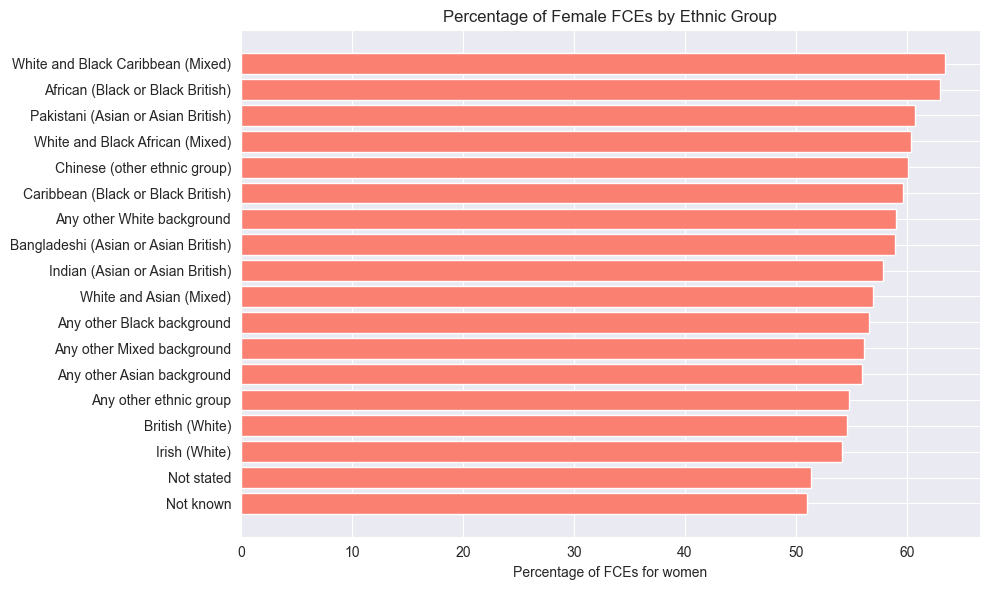

In [21]:
demog_pct = demog_sex_df.copy()

# Total male and female FCE per group
demog_pct['Total_MF_FCE'] = demog_pct['Male_FCE'] + demog_pct['Female_FCE']

# Calculate percentage of female episodes
demog_pct['Female_pct'] = demog_pct.apply(
    lambda row: (row['Female_FCE'] / row['Total_MF_FCE']) * 100 if row['Total_MF_FCE'] > 0 else None,
    axis=1
)

demog_pct_sorted = demog_pct.sort_values('Female_pct', ascending=False)

plt.figure()
plt.barh(demog_pct_sorted['Ethnic_Description'], demog_pct_sorted['Female_pct'], color='salmon')
plt.xlabel('Percentage of FCEs for women')
plt.title('Percentage of Female FCEs by Ethnic Group')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Our project asks the question ‘Is healthcare more expensive for cisgender men vs women, and how so?’

The cleaned demographics dataset and corresponding visuals provide important context for this question. This data does not show costs directly but does show how often men and women use inpatient hospital services broken down by ethnic group.

The first bar chart (total FCEs by sex) shows that women have a higher number of FCEs than men overall which suggests that before we take costs into consideration, women may account for a larger share of inpatient activity.

The second bar chart shows that this pattern is repeated across most ethnic categories. It is important to take into account how frequently men and women use hospital care when comparing healthcare costs.

The last bar chart shows what proportion of episodes are by women for each ethnic group. This helps identify ethnic groups where the gender imbalance in usage is strong. We can use this information to explore whether higher spending by women is mainly due to higher usage, higher cost per episode or a combination of both.

## Hospital Admitted Patient Care - Diagnosis

This dataset reports on Admitted Patient Care activity in England for the financial year 2023-24. The records refer to 'Finished Consultant Episodes', and each episode relates to a period of care for a patient under a single consultant at a single hospital.

In [22]:
# Hospital admitted patient care 2023-24 - Primary Diagnosis Summary table
diagnosis_summary_df = pd.read_csv('../data/clean/diagnosis_summary_clean.csv')

# Hospital admitted patient care 2023-24 - Primary Diagnosis 3 Character code table
diagnosis_3_char_df = pd.read_csv('../data/clean/diagnosis_3_char_clean.csv')

In [23]:
# sampling the data and looking at data types and shape

print(diagnosis_summary_df.sample(5))
print(diagnosis_summary_df.info())

print(diagnosis_3_char_df.sample(5))
print(diagnosis_3_char_df.info())

        code                                        description     sex  \
420  T79-T79              Certain early complications of trauma  Female   
352  N20-N23                                       Urolithiasis  Female   
4    A50-A64  Infections with a predominantly sexual mode of...    Male   
401  R95-R99          Ill-defined & unknown causes of mortality  Female   
331  K65-K67                             Diseases of peritoneum  Female   

     diagnosis_count                                           category  
420             3358  Injury, poisoning and certain other consequenc...  
352            33518     Diseases of the genitourinary system (N00–N99)  
4               1388  Certain infectious and parasitic diseases (A00...  
401                4  Symptoms, signs and abnormal clinical and labo...  
331             7531         Diseases of the digestive system (K00–K93)  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 432 entries, 0 to 431
Data columns (total 5 columns):
 

Text(0, 0.5, 'Diagnosis Count')

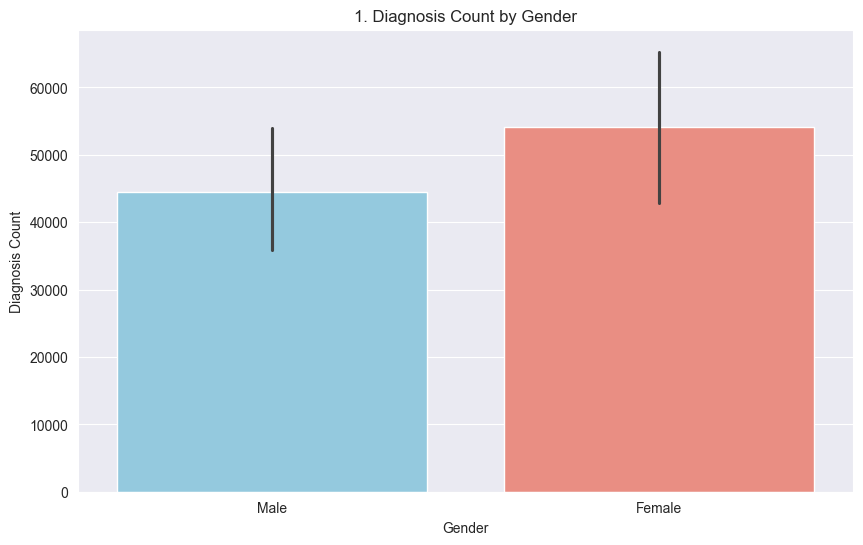

In [24]:
palette = {"Female": "salmon", "Male": "skyblue"}

sns.barplot(
    data=diagnosis_summary_df, x="sex", y="diagnosis_count", hue="sex", palette=palette
)
plt.title('1. Diagnosis Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Diagnosis Count')

In [25]:
# making wide version of dataframe to add totals column
diagnosis_summary_wide = diagnosis_summary_df.pivot(index='description', columns='sex', values='diagnosis_count')
diagnosis_summary_wide['total'] = diagnosis_summary_wide.sum(axis=1)

diagnosis_summary_wide.head()

sex,Female,Male,total
description,,,
Abnormal findings on diagnostic imaging/function studies,31251,28206,59457
"Abnormal findings on examination of blood, without diagnosis",15691,24007,39698
"Abnormal findings on examination of other body fluids, substances and tissues, without diagnosis",2350,707,3057
"Abnormal findings on examination of urine, without diagnosis",734,743,1477
Acute rheumatic fever,73,52,125


In [26]:
top_10_diagnoses = diagnosis_summary_wide.sort_values(by=['total'], ascending=False).head(10)
display(top_10_diagnoses)

sex,Female,Male,total
description,,,
Disorders of lens (including cataracts),437026,308994,746020
Other diseases of intestines,380042,351026,731068
General symptoms & signs,373440,318562,692002
Influenza & pneumonia,313724,310456,624180
Other forms of heart disease,253225,328884,582109
Symptoms & signs inv. the digestive system & abdomen,368544,197018,565562
Arthropathies,333696,227662,561358
Health services in circumstances related to reproduction,316606,184215,500821
"Diseases of oesophagus, stomach & duodenum",254757,244242,498999


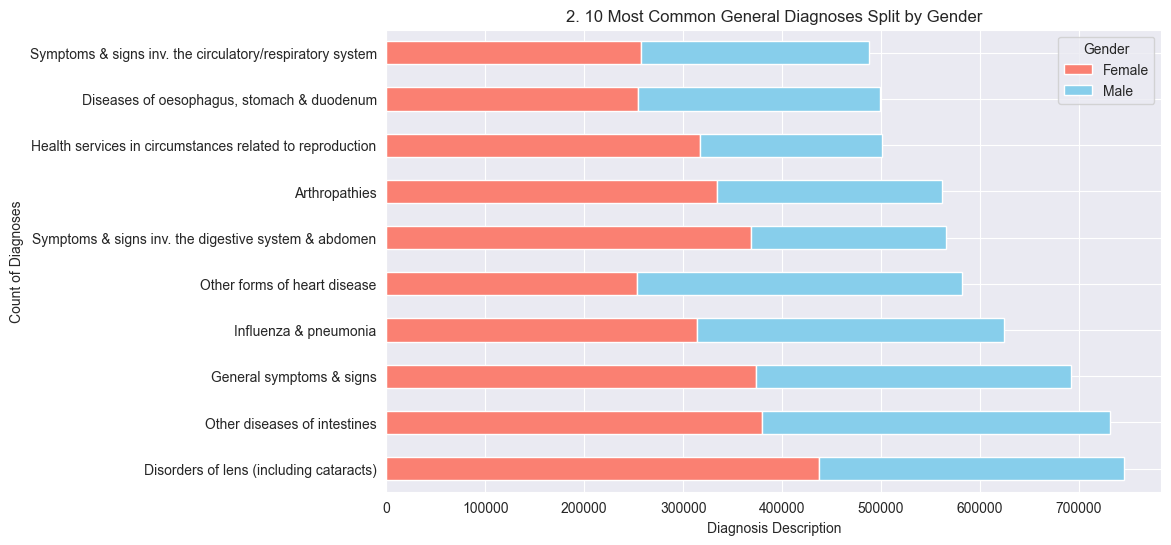

In [27]:
diag_10_subset = top_10_diagnoses[["Female", "Male"]]

diag_10_subset.plot(kind='barh', stacked=True, color=['salmon', 'skyblue'])
plt.title('2. 10 Most Common General Diagnoses Split by Gender')
plt.xlabel('Diagnosis Description')
plt.ylabel('Count of Diagnoses')

plt.legend(title='Gender')

Text(0, 0.5, 'Category')

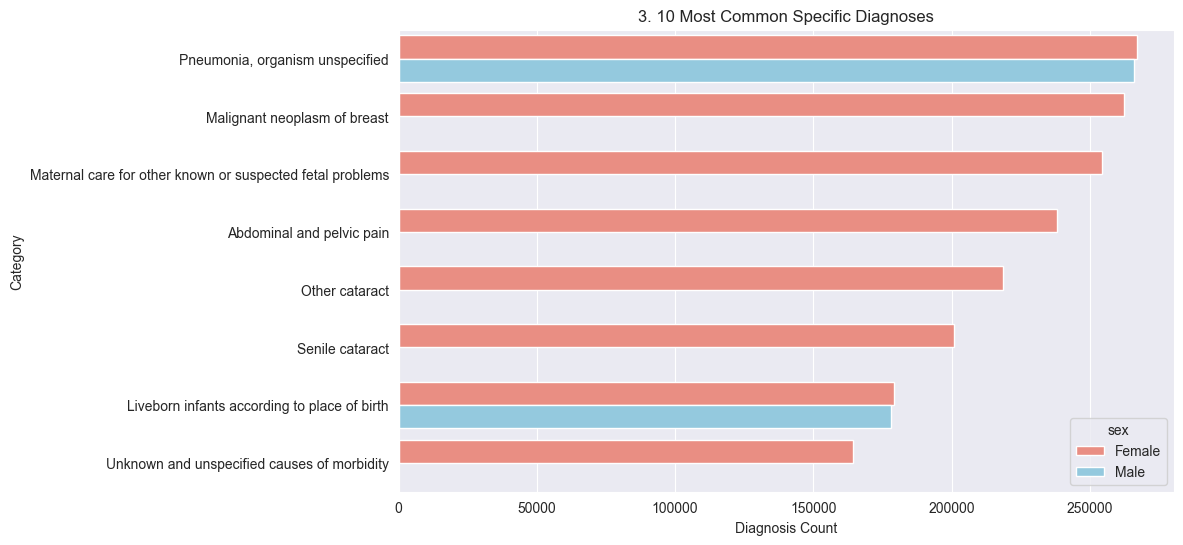

In [28]:
top_10_3_char = diagnosis_3_char_df.sort_values(by='diagnosis_count', ascending=False).head(10)
top_10_3_char_plot = sns.barplot(top_10_3_char, x='diagnosis_count', y='description', hue='sex', palette=palette)
plt.title('3. 10 Most Common Specific Diagnoses')
plt.xlabel('Diagnosis Count')
plt.ylabel('Category')

Plot 2 above shows the 10 most common general diagnoses in hospital admitted patient care in the 2023-24 period, based on the summary dataset which groups types of diagnosis. This takes into account the total number of diagnoses including men and women.

Plot 3 shows the 10 most frequently diagnosed conditions in the dataset. Neoplasms of the breast and maternal care are female-specific, however the female patients receive more diagnoses of non-gender-specific conditions.

Across both plots, more diagnoses were given to women than men in the majority of the top 10.

The only diagnosis area in which men had a significantly greater diagnosis count was heart disease.

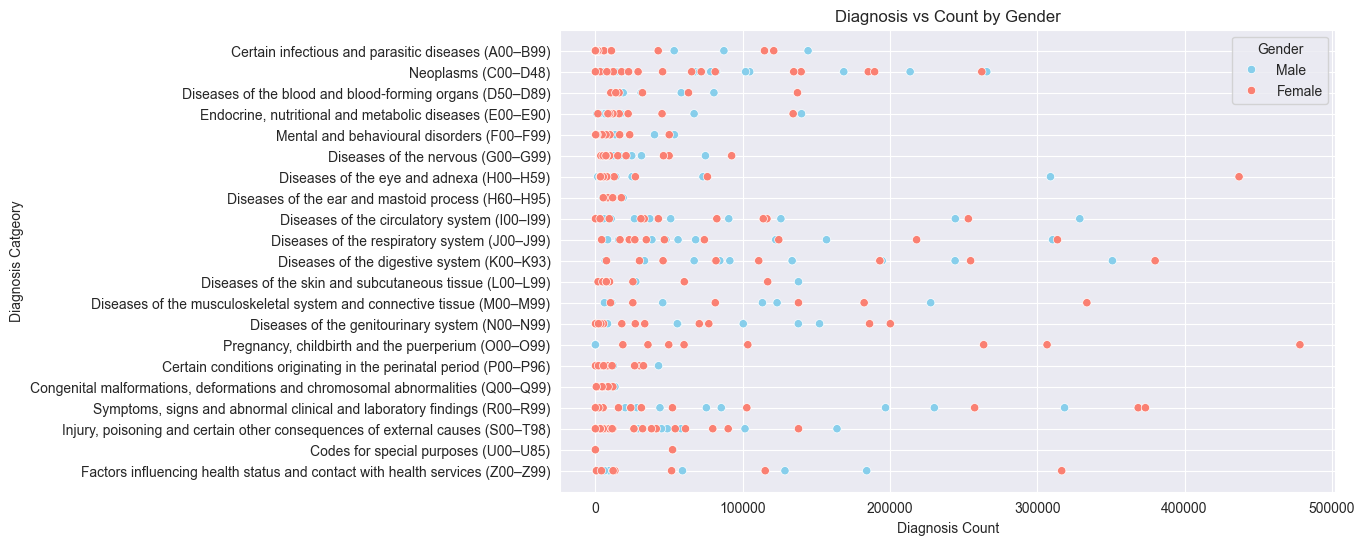

In [29]:
sns.scatterplot(data=diagnosis_summary_df, y='category', x='diagnosis_count', hue='sex', palette=palette)
plt.title('Diagnosis vs Count by Gender')
plt.xlabel('Diagnosis Count')
plt.ylabel('Diagnosis Catgeory')
plt.legend(title='Gender')

Plotting the diagnosis counts by category in a scatter graph shows the spread of diagnosis counts by catgeory, and there are no significant outliers. Outliers did not cause an issue when processing this data as it is already aggregated and of a high quality due to being sourced from the NHS.

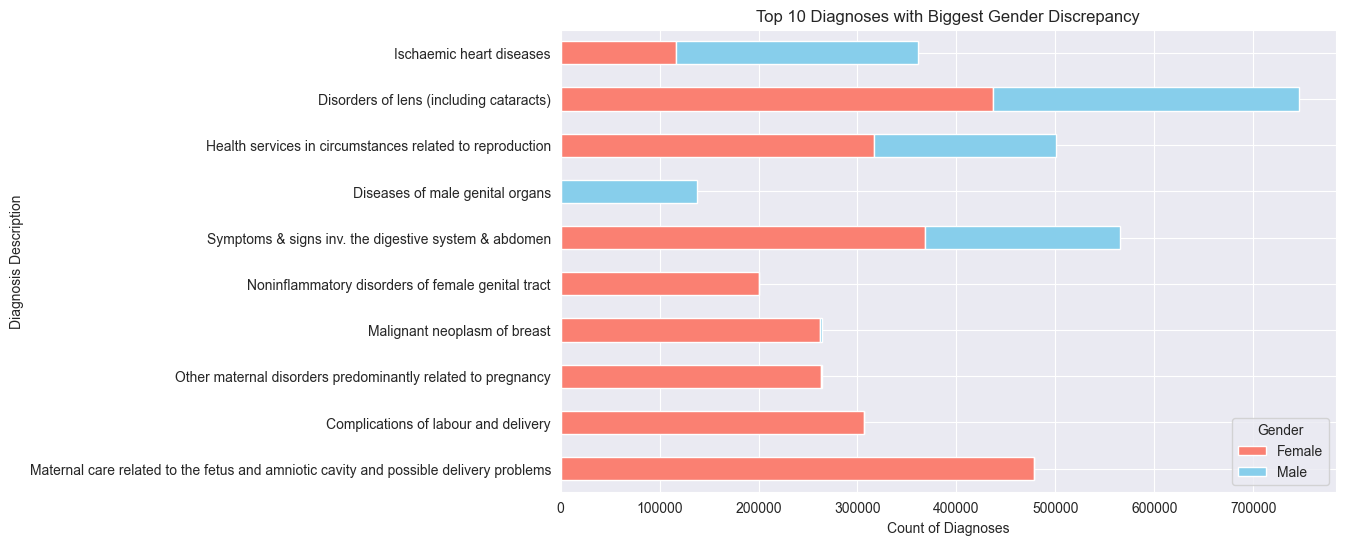

In [30]:
discrepancy_df = diagnosis_summary_wide.copy()
discrepancy_df['discrepancy'] = abs(discrepancy_df['Female'] - discrepancy_df['Male'])

top_discrepancy_diagnoses = discrepancy_df.sort_values(by='discrepancy', ascending=False).head(10)

top_discrepancy_diagnoses[['Female', 'Male']].plot(kind='barh', stacked=True, color=['salmon', 'skyblue'])

plt.title('Top 10 Diagnoses with Biggest Gender Discrepancy')
plt.xlabel('Count of Diagnoses')
plt.ylabel('Diagnosis Description')
plt.legend(title='Gender')
plt.show()

Text(0, 0.5, 'Category')

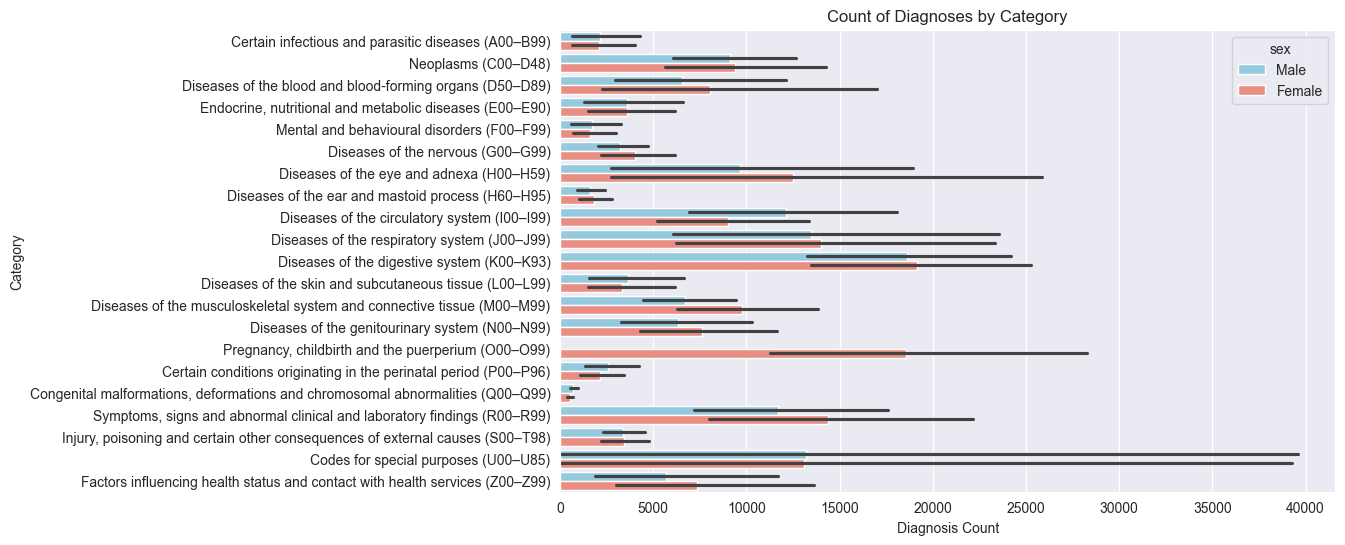

In [31]:
category_plot = sns.barplot(diagnosis_3_char_df, x='diagnosis_count', y='category', hue='sex', palette=palette)
plt.title('Count of Diagnoses by Category')
plt.xlabel('Diagnosis Count')
plt.ylabel('Category')

Categories with significant differences between male and female (excluding pregancy):
* Diseases of the blood and blood–forming organs
* Diseases of the eye and adnexa
* Diseases of the circulatory system
* Diseases of the musculoskeletal system and connective tissue
* Symptoms, signs and abnormal clinical and laboratory findings
* Factors influencing health status and contact with health services

Text(0, 0.5, 'Count')

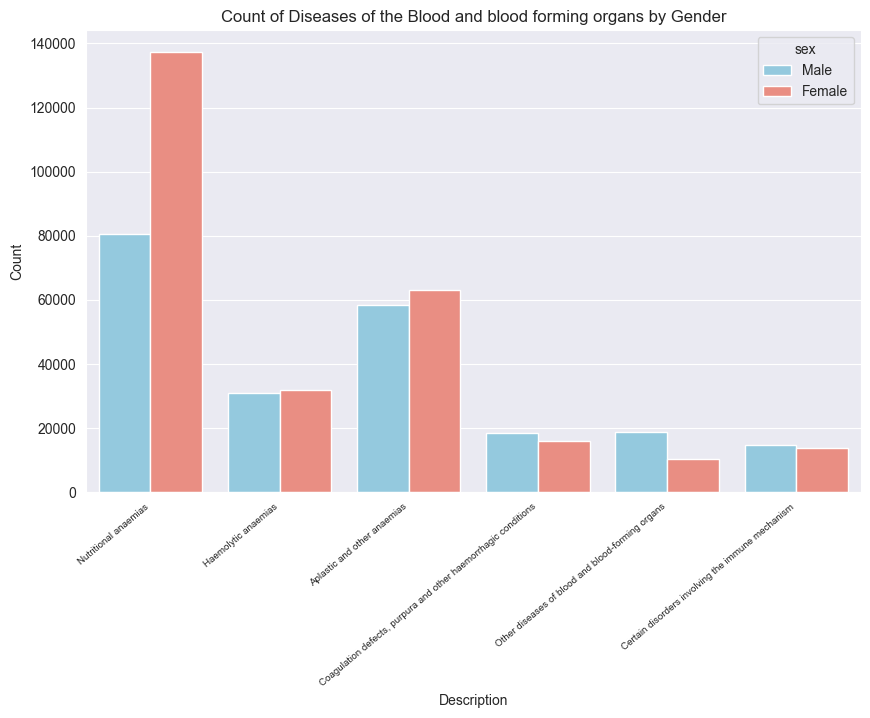

In [32]:
blood_diag_df = diagnosis_summary_df[diagnosis_summary_df['category'].str.contains('blood')]
blood_plot = sns.barplot(blood_diag_df, x='description', y='diagnosis_count', hue='sex', palette=palette)
plt.xticks(rotation=40, ha="right", fontsize=7)
plt.title('Count of Diseases of the Blood and blood forming organs by Gender')
plt.xlabel('Description')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

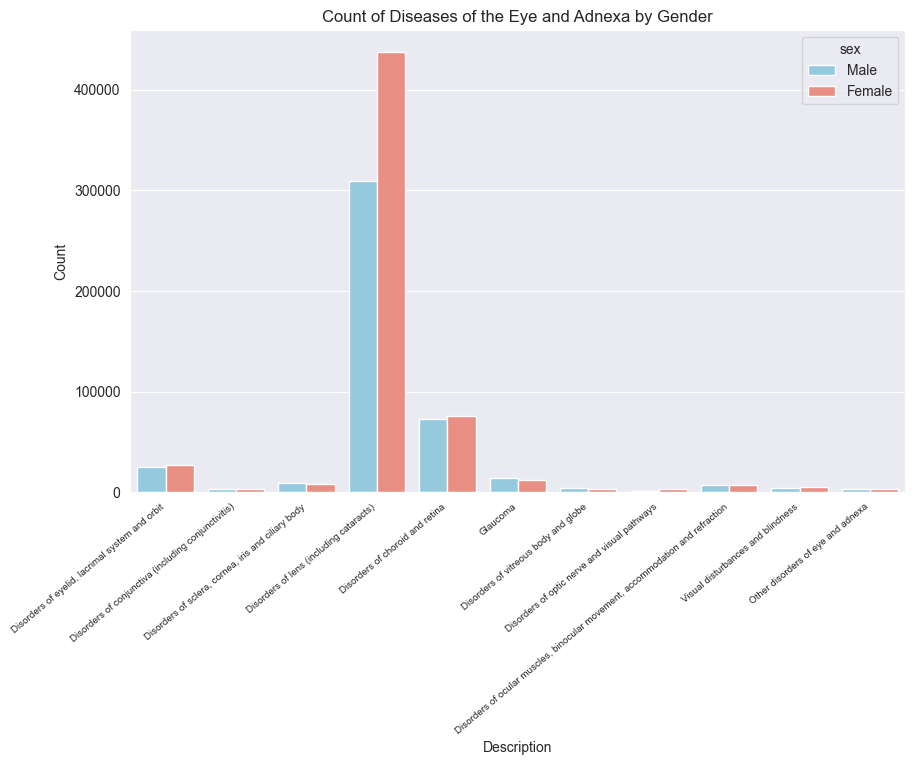

In [33]:
adnexa_diag_df = diagnosis_summary_df[diagnosis_summary_df['category'].str.contains('adnexa')]
adnexa_plot = sns.barplot(adnexa_diag_df, x='description', y='diagnosis_count', hue='sex', palette=palette)
plt.xticks(rotation=40, ha="right", fontsize=7)
plt.title('Count of Diseases of the Eye and Adnexa by Gender')
plt.xlabel('Description')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

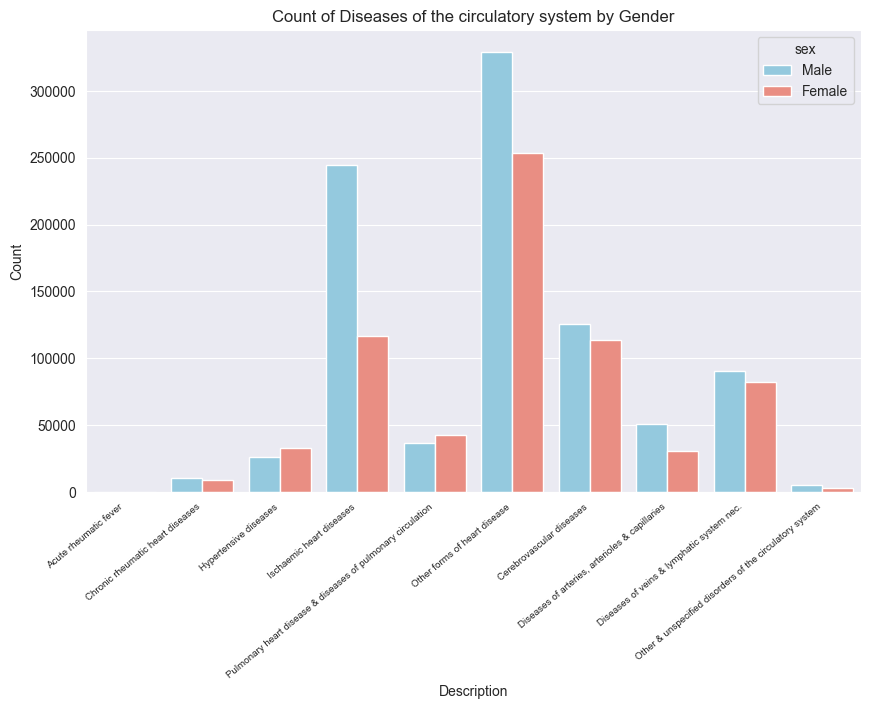

In [34]:
circ_diag_df = diagnosis_summary_df[diagnosis_summary_df['category'].str.contains('circulatory')]
circ_plot = sns.barplot(circ_diag_df, x='description', y='diagnosis_count', hue='sex', palette=palette)
plt.xticks(rotation=40, ha="right", fontsize=7)
plt.title('Count of Diseases of the circulatory system by Gender')
plt.xlabel('Description')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

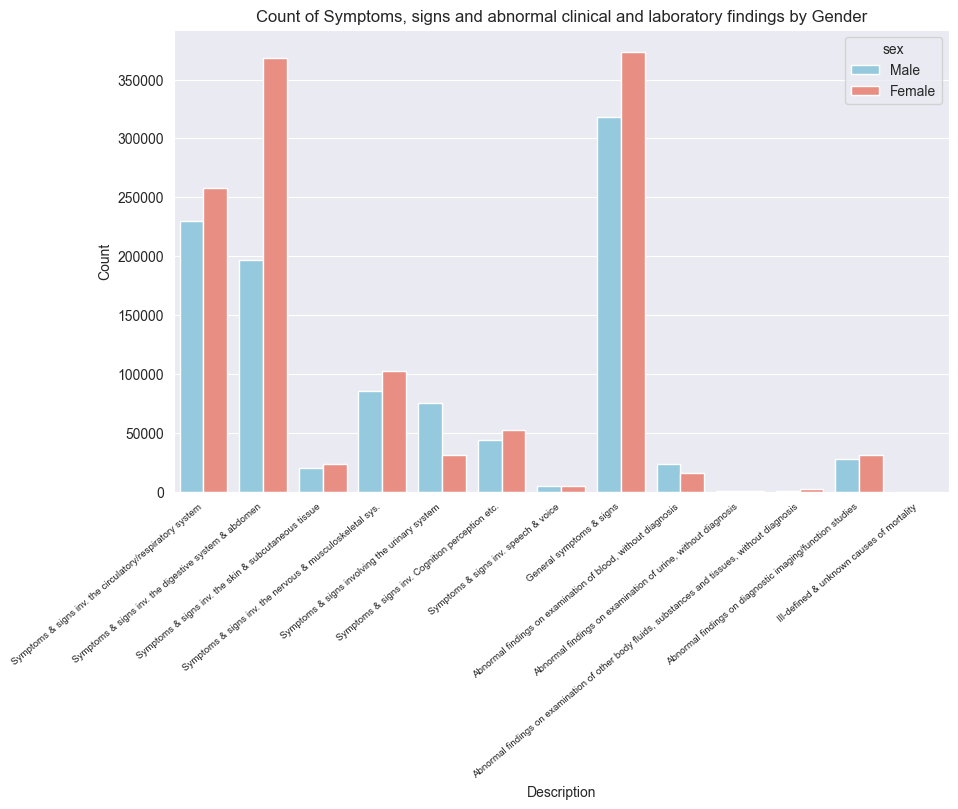

In [35]:
signs_diag_df = diagnosis_summary_df[diagnosis_summary_df['category'].str.contains('R00')]
signs_plot = sns.barplot(signs_diag_df, x='description', y='diagnosis_count', hue='sex', palette=palette)
plt.xticks(rotation=40, ha="right", fontsize=7)
plt.title('Count of Symptoms, signs and abnormal clinical and laboratory findings by Gender')
plt.xlabel('Description')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

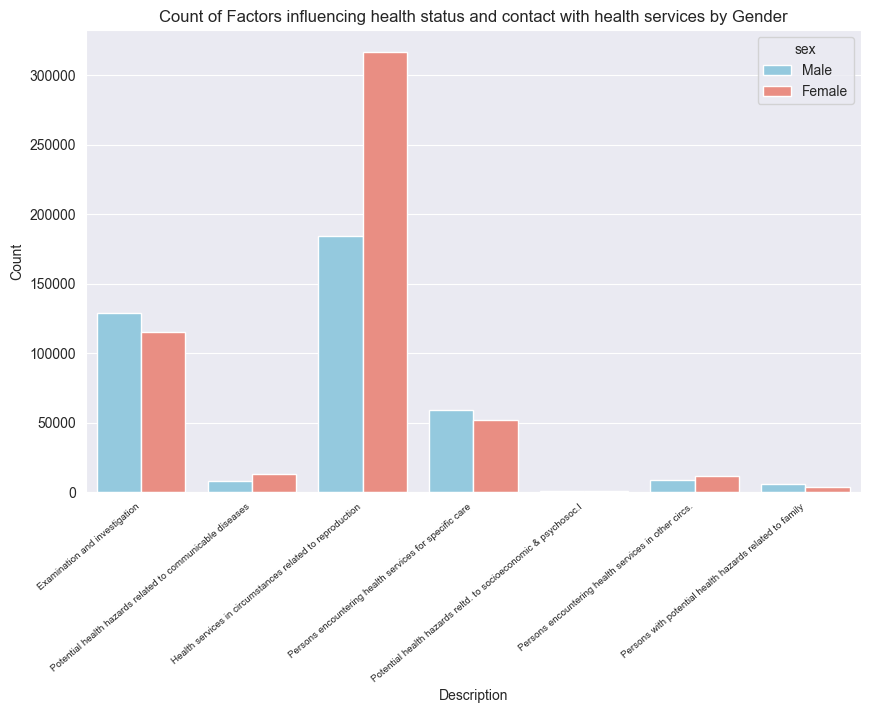

In [36]:
factors_diag_df = diagnosis_summary_df[diagnosis_summary_df['category'].str.contains('Z00')]
factors_plot = sns.barplot(factors_diag_df, x='description', y='diagnosis_count', hue='sex', palette=palette)
plt.xticks(rotation=40, ha="right", fontsize=7)
plt.title('Count of Factors influencing health status and contact with health services by Gender')
plt.xlabel('Description')
plt.ylabel('Count')

Types of injury may suggest differences in behaviour patterns.

The plot below shows:
* Male patients received a greater number of head, arm and hand injuries which could correlate with sports or manual work which are more commonly associated with men.
* Female patients had higher numbers of injuries to the lower body. The pelvis, hips and spine can be affected by pregnancy and childbirth, which may be a factor.

Text(0, 0.5, 'Count')

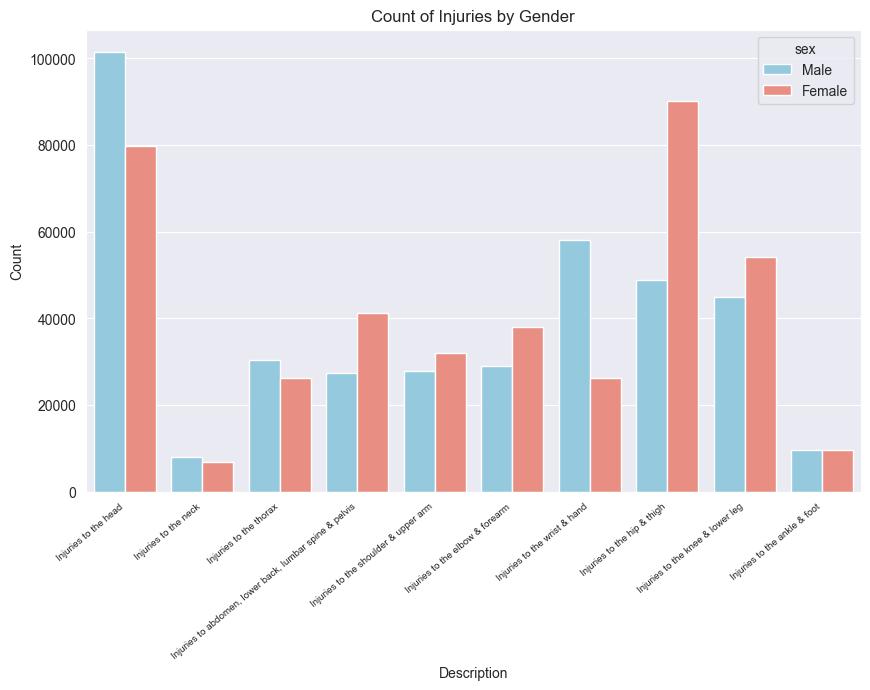

In [37]:
injuries_diag_df = diagnosis_summary_df[diagnosis_summary_df['code'].map(lambda x: x.startswith('S'))]
injuries_plot = sns.barplot(injuries_diag_df, x='description', y='diagnosis_count', hue='sex', palette=palette)
plt.xticks(rotation=40, ha="right", fontsize=7)
plt.title('Count of Injuries by Gender')
plt.xlabel('Description')
plt.ylabel('Count')

Women received more diagnoses overall

Women received a higher proportion of the most common diagnoses when individual descriptions and total overall numbers were taken into account.

In most categories where there were notable differences between diagnoses given to male and female patients, a greater number were given to women - with the exception of heart disease.

Injuries show differences that may correlate with physical differences but also behaviour patterns.

Beyond diagnoses explicitly relating to reproduction, women received noticeable higher diagnoses of:

- cataracts
- anaemia
- symptoms relating to the digestive system and abdomen

Preventative measures in these areas could help address the balance of healthcare needs across men and women.

The data counts consultant episodes (i.e. individual instances of attending hospital and receiving a diagnosis) rather than individual patients, so inflated numbers for women may also include repeated visits by certain individuals. This could suggest poorer health overall, or multiple visits being required before a final diagnosis is reached.

## Hospital Admitted Patient Care - Procedures

In [52]:
analysis_df = pd.read_csv("../data/clean/cleaned_procedures_analysis.csv")
analysis_df.head()

,procedure_group,male_fce,female_fce
0,A1 Tissue of brain (A01-A11),5491,4382
1,A2 Ventricle of brain and subarachnoid space (...,3706,3695
2,A3 Cranial nerves (A24-A36),1462,1851
3,A4 Meninges of brain (A38-A43),3541,2663
4,A5 Spinal cord and other contents of spinal ca...,61877,79476


In [53]:
total_male = analysis_df['male_fce'].sum()
total_female = analysis_df['female_fce'].sum()

total_male, total_female

(np.int64(5830142), np.int64(6863739))

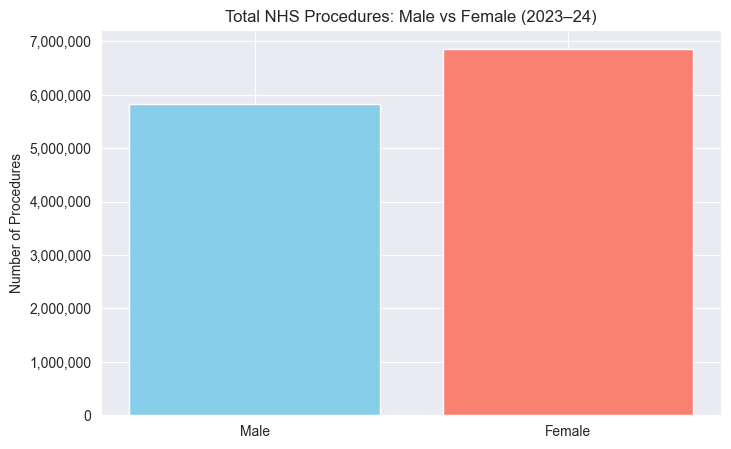

In [75]:
plt.figure(figsize=(8,5))
plt.bar(['Male', 'Female'], [total_male, total_female], color=["skyblue", "salmon"])
plt.title('Total NHS Procedures: Male vs Female (2023–24)')
plt.ylabel('Number of Procedures')

# Show full numbers instead of 1e6
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.show()

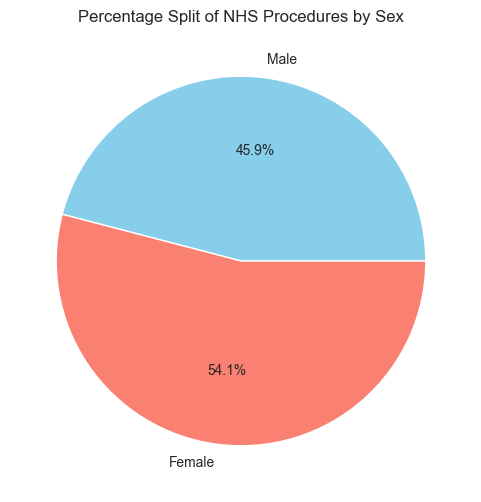

In [63]:
totals = {'Male': total_male, 'Female': total_female}
plt.figure(figsize=(6,6))
plt.pie(totals.values(), labels=totals.keys(), autopct="%1.1f%%", colors=["skyblue", "salmon"])
plt.title("Percentage Split of NHS Procedures by Sex")
plt.show()

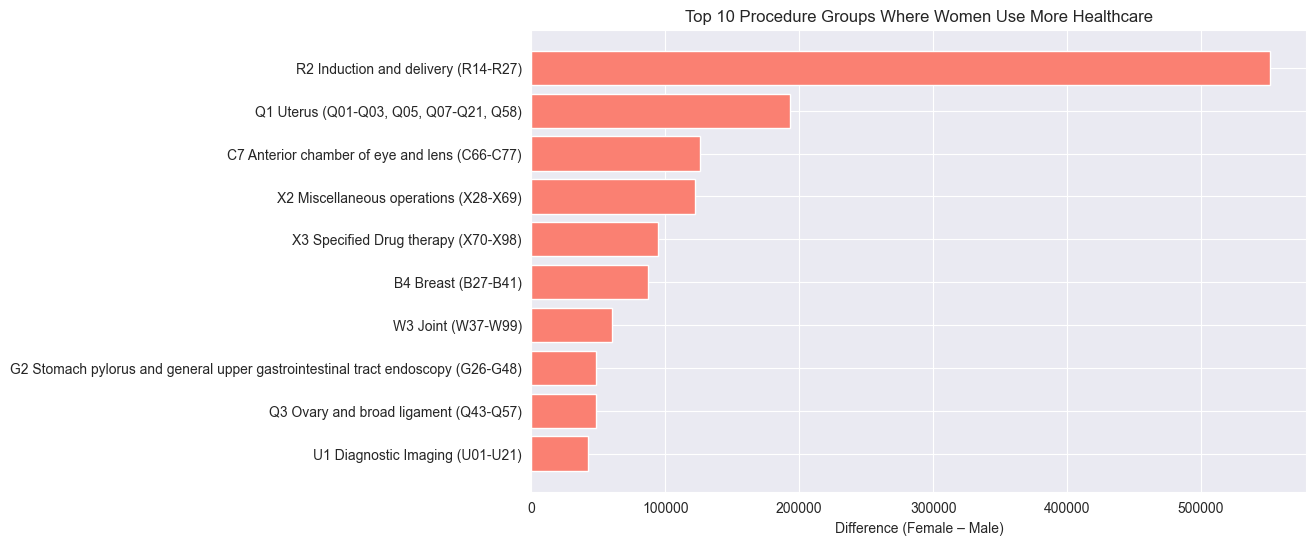

In [65]:
diff_df = analysis_df.copy()
diff_df['difference'] = diff_df['female_fce'] - diff_df['male_fce']
top_female = diff_df.nlargest(10, 'difference')

plt.figure(figsize=(10,6))
plt.barh(top_female['procedure_group'], top_female['difference'], color="salmon")
plt.title("Top 10 Procedure Groups Where Women Use More Healthcare")
plt.xlabel("Difference (Female – Male)")
plt.gca().invert_yaxis()
plt.show()

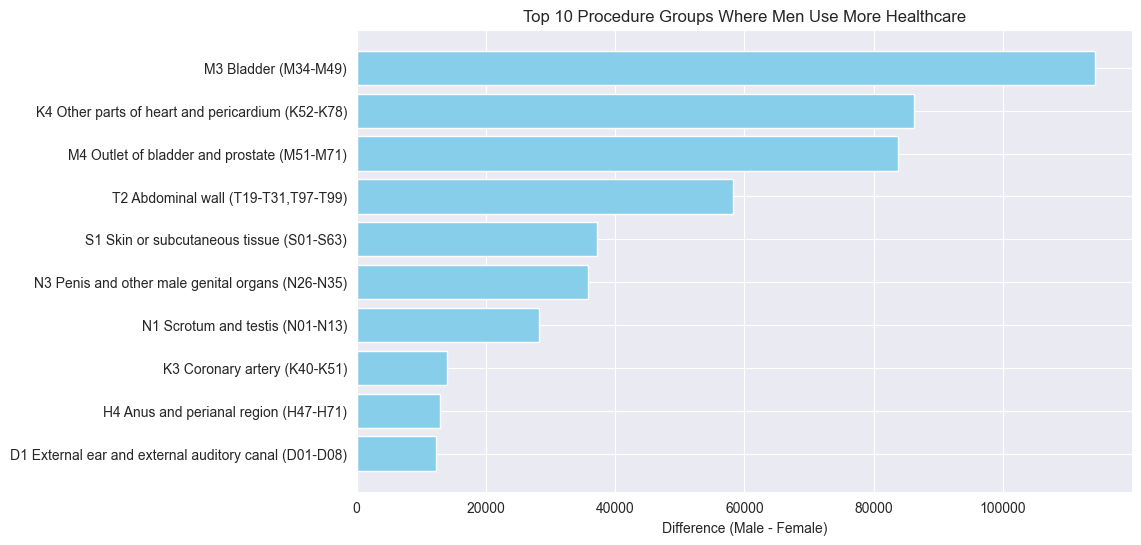

In [66]:
diff_df = analysis_df.copy()
diff_df['difference'] = diff_df['male_fce'] - diff_df['female_fce']
top_female = diff_df.nlargest(10, 'difference')

plt.figure(figsize=(10,6))
plt.barh(top_female['procedure_group'], top_female['difference'], color="skyblue")
plt.title("Top 10 Procedure Groups Where Men Use More Healthcare")
plt.xlabel("Difference (Male - Female)")
plt.gca().invert_yaxis()
plt.show()

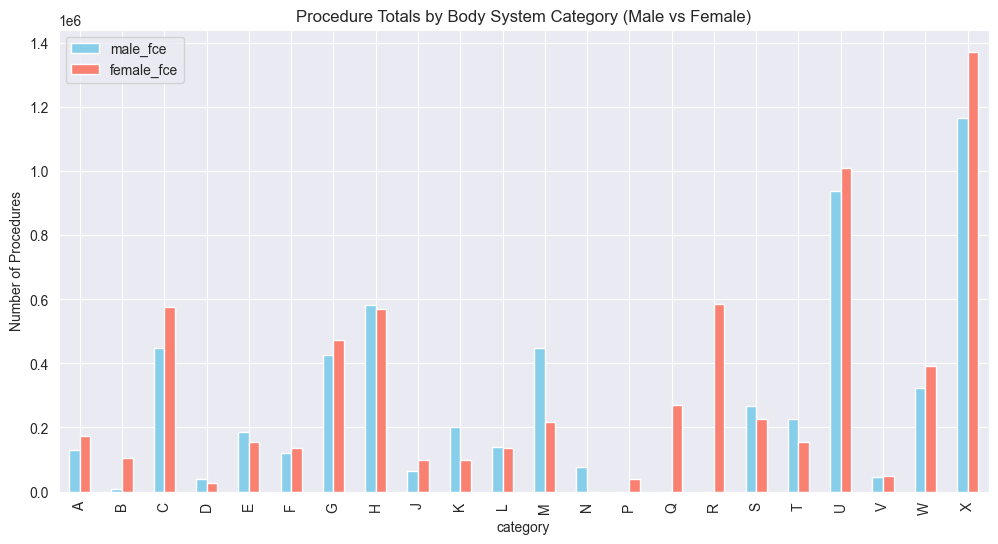

In [67]:
analysis_df['category'] = analysis_df['procedure_group'].str[0]  # first letter (S, T, U, W, etc.)
category_totals = analysis_df.groupby('category')[['male_fce','female_fce']].sum()

category_totals.plot(kind="bar", figsize=(12,6), color=["skyblue", "salmon"])
plt.title("Procedure Totals by Body System Category (Male vs Female)")
plt.ylabel("Number of Procedures")
plt.show()

In [68]:
analysis_df['prefix'] = analysis_df['procedure_group'].str.extract(r'^([A-Z]\d)')

In [69]:
key_table = (
    analysis_df[['prefix', 'procedure_group']]
    .drop_duplicates('prefix')
    .assign(description=lambda df: df['procedure_group'].str.extract(r'^[A-Z]\d\s(.+?)\s?\(')[0])
    [['prefix', 'description']]
    .sort_values('prefix')
    .reset_index(drop=True)
)

key_table

,prefix,description
0,A1,Tissue of brain
1,A2,Ventricle of brain and subarachnoid space
2,A3,Cranial nerves
3,A4,Meninges of brain
4,A5,Spinal cord and other contents of spinal canal
...,...,...
95,W3,Joint
96,W4,Overflow other bones and joints
97,X1,Operations covering multiple systems
98,X2,Miscellaneous operations


<Axes: ylabel='procedure_group'>

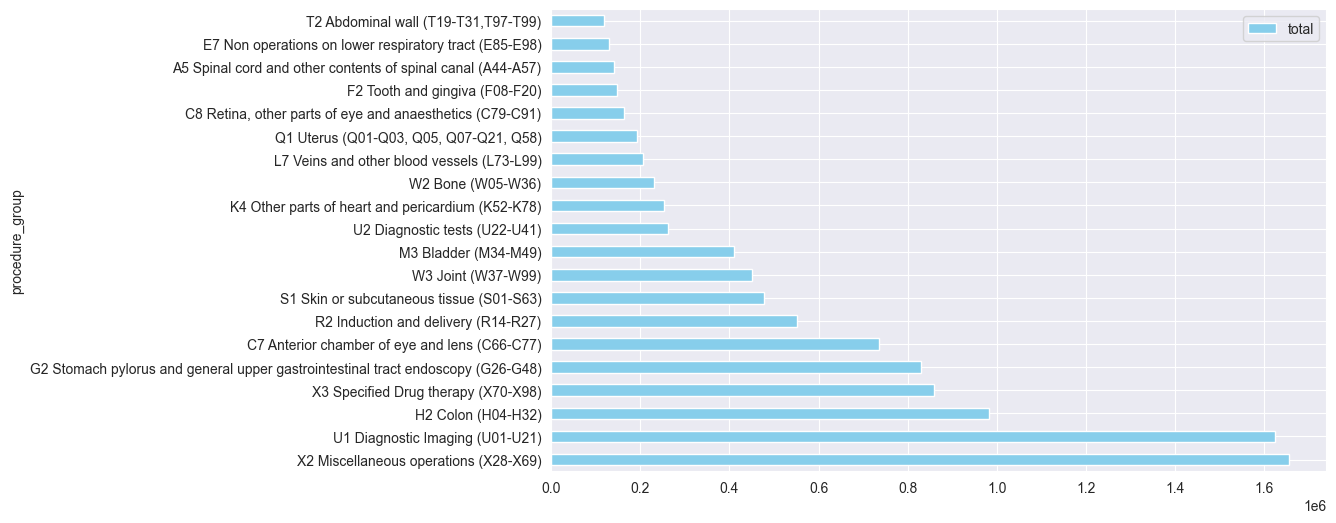

In [71]:
analysis_df['total'] = analysis_df['male_fce'] + analysis_df['female_fce']
top20 = analysis_df.nlargest(20, 'total')

top20.plot(x='procedure_group', y='total', kind='barh', color='skyblue')

In [76]:
# Create a total column just for sorting
analysis_df['total_fce'] = analysis_df['male_fce'] + analysis_df['female_fce']

# Pick top 10 procedures by total FCE
top10 = (
    analysis_df
    .sort_values('total_fce', ascending=False)
    .head(10)
    .copy()
)

top10

,procedure_group,male_fce,female_fce,category,prefix,total,total_fce
98,X2 Miscellaneous operations (X28-X69),767143,888960,X,X2,1656103,1656103
88,U1 Diagnostic Imaging (U01-U21),790908,833152,U,U1,1624060,1624060
41,H2 Colon (H04-H32),490813,491946,H,H2,982759,982759
99,X3 Specified Drug therapy (X70-X98),381968,476251,X,X3,858219,858219
36,G2 Stomach pylorus and general upper gastroint...,390403,438758,G,G2,829161,829161
17,C7 Anterior chamber of eye and lens (C66-C77),304891,430967,C,C7,735858,735858
76,R2 Induction and delivery (R14-R27),1,551172,R,R2,551173,551173
79,S1 Skin or subcutaneous tissue (S01-S63),257200,220011,S,S1,477211,477211
95,W3 Joint (W37-W99),195311,255638,W,W3,450949,450949
64,M3 Bladder (M34-M49),262645,148387,M,M3,411032,411032


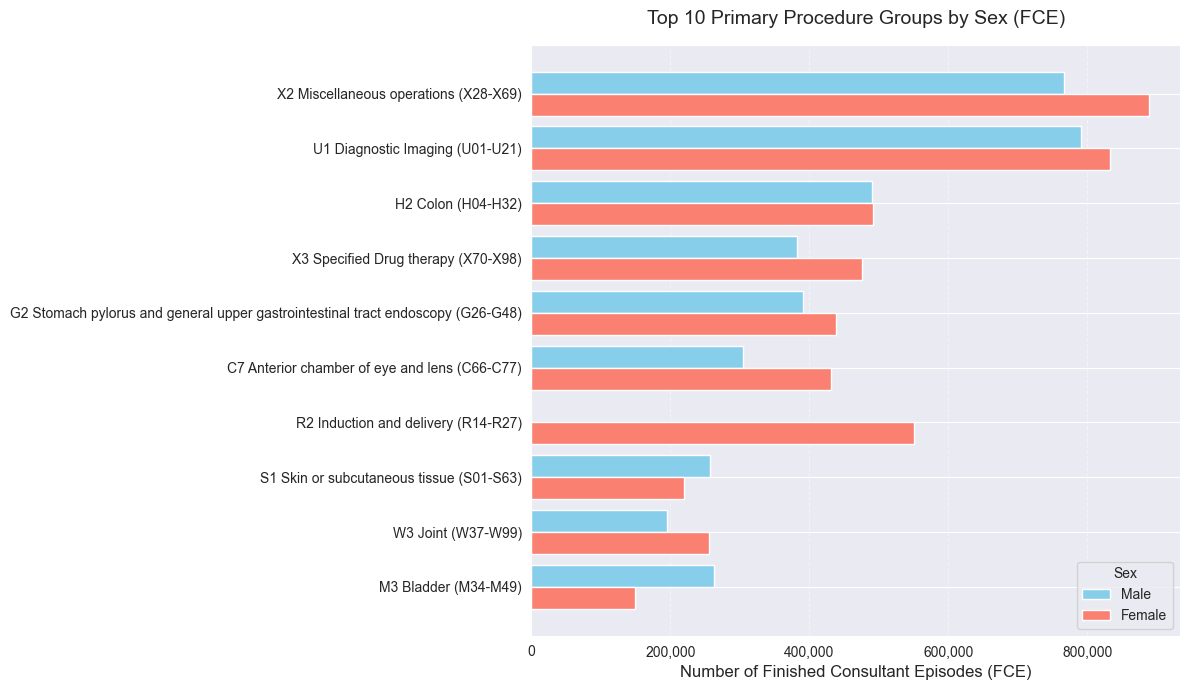

In [79]:
x = np.arange(len(top10))
bar_height = 0.4

fig, ax = plt.subplots(figsize=(12, 7))

ax.barh(x - bar_height/2, top10['male_fce'],  height=bar_height, label='Male', color="skyblue")
ax.barh(x + bar_height/2, top10['female_fce'], height=bar_height, label='Female', color="salmon")


ax.set_yticks(x)
ax.set_yticklabels(top10['procedure_group'])


ax.invert_yaxis()

# Titles & labels
ax.set_title("Top 10 Primary Procedure Groups by Sex (FCE)", fontsize=14, pad=15)
ax.set_xlabel("Number of Finished Consultant Episodes (FCE)", fontsize=12)

# Format x-axis with commas
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))


ax.legend(title="Sex")


ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Patient Level Activity 2022-22

In [82]:
file_path = "../data/raw/Integrated-Patient-Level-Activity-and-Costing-2021-22.csv"

activity_21_22_df = pd.read_csv(file_path)

# light clean
activity_21_22_df["BREAKDOWN_GROUP_1"] = activity_21_22_df["BREAKDOWN_GROUP_1"].astype(str).str.strip()
activity_21_22_df["BREAKDOWN_GROUP_2"] = activity_21_22_df["BREAKDOWN_GROUP_2"].astype(str).str.strip()
activity_21_22_df["ACTIVITY_COUNT"] = pd.to_numeric(activity_21_22_df["ACTIVITY_COUNT"], errors="coerce")
activity_21_22_df["TOTAL_COST"] = pd.to_numeric(activity_21_22_df["TOTAL_COST"], errors="coerce")
activity_21_22_df = activity_21_22_df.dropna(subset=["ACTIVITY_COUNT", "TOTAL_COST"], how="all")

# focus only on Male / Female
gender_df = activity_21_22_df[activity_21_22_df["BREAKDOWN_GROUP_1"].isin(["Male", "Female"])].copy()

# age rows
age_df = gender_df[
    gender_df["BREAKDOWN_GROUP_2"].str.contains("years", case=False, na=False)
].copy()

# sorting age bands
def get_start_age(age_text: str) -> int:
    first = age_text.split("-")[0].split()[0]
    return int(first)

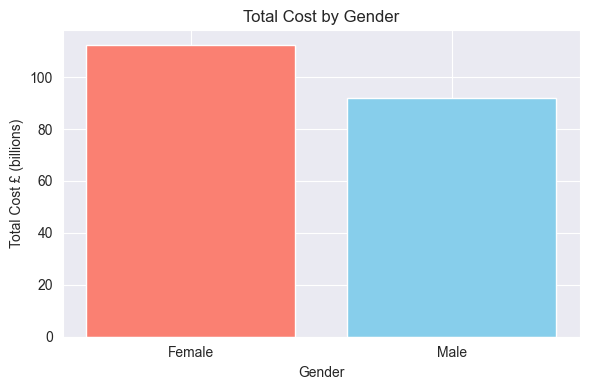

In [85]:
gender_cost = (
    gender_df.groupby("BREAKDOWN_GROUP_1")[["TOTAL_COST"]]
    .sum()
    .reset_index()
)

plt.figure(figsize=(6,4))
plt.bar(gender_cost["BREAKDOWN_GROUP_1"], gender_cost["TOTAL_COST"] /1e9, color=my_colours) # 1e9 tells the number of zeros in this case 9
plt.title("Total Cost by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Cost £ (billions)")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}")) # reformats it to the appropriate decimal place on the x-axis
plt.tight_layout()
plt.show()

**Plot Summary**
- Women's health costs more on the NHS than Men

**Interpretation**
- Data suggests that spending on the NHS is greater for Women than it is for Men
- These figures reflect healthcare usage costs, so can be deemed a trustworthy reliable indicator
- The chart provides context for gender-based spending patterns across the NHS

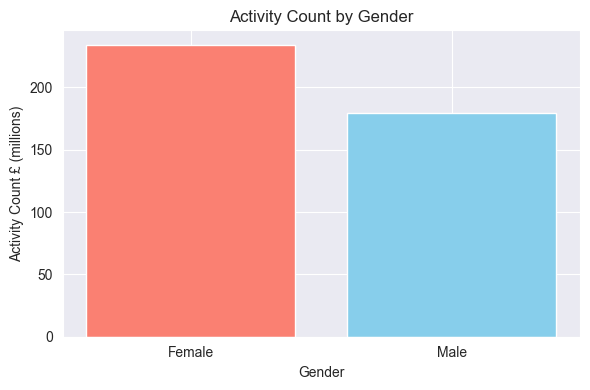

In [86]:
gender_activity = (
    gender_df
    .groupby("BREAKDOWN_GROUP_1")[["ACTIVITY_COUNT"]]
    .sum()
    .reset_index()
)

plt.figure(figsize=(6, 4))
plt.bar(gender_activity["BREAKDOWN_GROUP_1"], gender_activity["ACTIVITY_COUNT"] / 1e6, color=my_colours) # 6 zeros
plt.title("Activity Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Activity Count £ (millions)")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}")) # to the decimal place
plt.tight_layout()
plt.show()

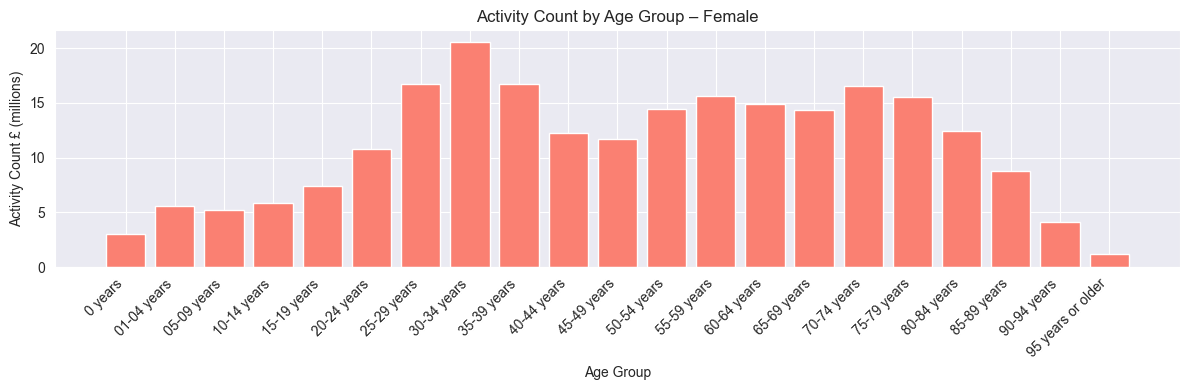

In [88]:
plt.show()
female_age = age_df[age_df["BREAKDOWN_GROUP_1"] == "Female"].copy()

female_age = (
    female_age
    .groupby("BREAKDOWN_GROUP_2")[["ACTIVITY_COUNT"]]
    .sum()
    .reset_index()
)

female_age["AGE_SORT"] = female_age["BREAKDOWN_GROUP_2"].apply(get_start_age)
female_age = female_age.sort_values("AGE_SORT")

plt.figure(figsize=(12, 4))
plt.bar(female_age["BREAKDOWN_GROUP_2"], female_age["ACTIVITY_COUNT"] / 1e6, color="salmon")
plt.title("Activity Count by Age Group – Female")
plt.xlabel("Age Group")
plt.ylabel("Activity Count £ (millions)")
plt.xticks(rotation=45, ha="right")

plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

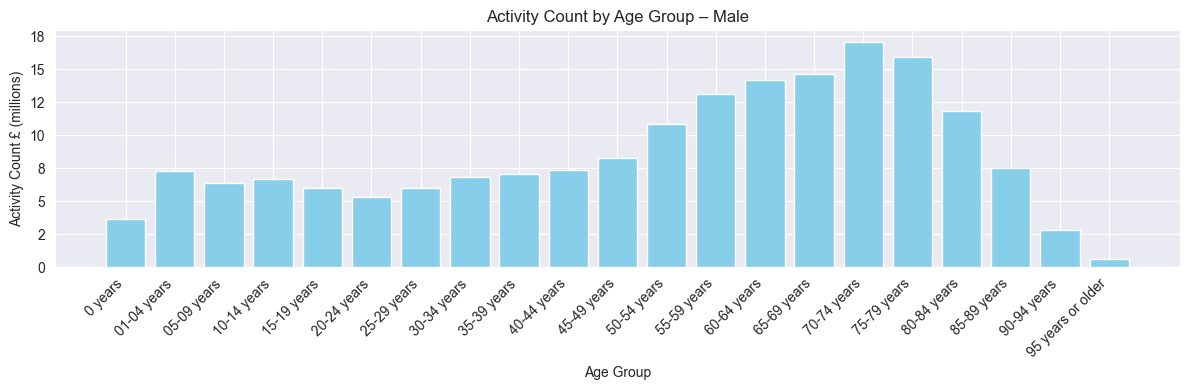

In [89]:
plt.show()
male_age = age_df[age_df["BREAKDOWN_GROUP_1"] == "Male"].copy()

male_age = (
    male_age
    .groupby("BREAKDOWN_GROUP_2")[["ACTIVITY_COUNT"]]
    .sum()
    .reset_index()
)

male_age["AGE_SORT"] = male_age["BREAKDOWN_GROUP_2"].apply(get_start_age)
male_age = male_age.sort_values("AGE_SORT")

plt.figure(figsize=(12, 4))
plt.bar(male_age["BREAKDOWN_GROUP_2"], male_age["ACTIVITY_COUNT"] / 1e6, color="skyblue")
plt.title("Activity Count by Age Group – Male")
plt.xlabel("Age Group")
plt.ylabel("Activity Count £ (millions)")
plt.xticks(rotation=45, ha="right")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

**Plot Summary**
- Across their later years, men tend to use NHS Services more so in later life than women

**Interpretation**
- Data suggests that spending on the NHS is greater for Men later than it is for Women
- These figures reflect healthcare usage costs, so can be deemed a trustworthy reliable indicator
- The chart provides context for gender-based spending patterns across the NHS